# Bengaluru house prices — EDA

Scope: **1 / 2 / 3 BHK** only. Target `price` is in **lakhs**.

Data: Kaggle `amitabhajoy/bengaluru-house-price-data` (same CSV as codebasics), ~13,320
listings from about **2017–18**. That vintage matters: every price below is a 2017-18 price
level, roughly half of what the same flat costs today. `src/price_index.py` handles the
correction — this notebook deliberately stays in the original units so the distributions
are the real ones.

Note what `clean_dataframe` does *not* do any more: it no longer trims outliers or imputes
missing `bath`/`balcony`. Both need to be learned from data, so they happen after the
train/test split in `src/train.py`. Doing them here would leak test prices into training.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data_loader import load_raw_data
from src.preprocess import clean_dataframe, extract_bhk

raw = load_raw_data()
print(raw.shape)
raw.head()

(13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [2]:
print(raw.isnull().sum())
print("\nLocations:", raw["location"].nunique())
raw["size"].value_counts().head(12)

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

Locations: 1305


size
2 BHK        5199
3 BHK        4310
4 Bedroom     826
4 BHK         591
3 Bedroom     547
1 BHK         538
2 Bedroom     329
5 Bedroom     297
6 Bedroom     191
1 Bedroom     105
8 Bedroom      84
7 Bedroom      83
Name: count, dtype: int64

In [3]:
raw = raw.copy()
raw["bhk_raw"] = raw["size"].map(extract_bhk)
print(raw["bhk_raw"].value_counts().sort_index())
print("1-3 BHK rows:", raw["bhk_raw"].isin([1, 2, 3]).sum())

bhk_raw
1.0      643
2.0     5528
3.0     4857
4.0     1417
5.0      356
6.0      221
7.0      100
8.0       89
9.0       54
10.0      14
11.0       4
12.0       1
13.0       1
14.0       1
16.0       1
18.0       1
19.0       1
27.0       1
43.0       1
Name: count, dtype: int64
1-3 BHK rows: 11028


In [4]:
clean = clean_dataframe(raw)
print(clean.shape)
print(clean["bhk"].value_counts().sort_index())
print(clean["location"].value_counts())

(10802, 7)
bhk
1.0     627
2.0    5478
3.0    4697
Name: count, dtype: int64
location
Other              2146
Whitefield          437
Sarjapur Road       359
Electronic City     285
Kanakpura Road      263
                   ... 
Basapura             10
Kalkere              10
Mico Layout          10
Gunjur Palya         10
Shivaji Nagar        10
Name: count, Length: 205, dtype: int64


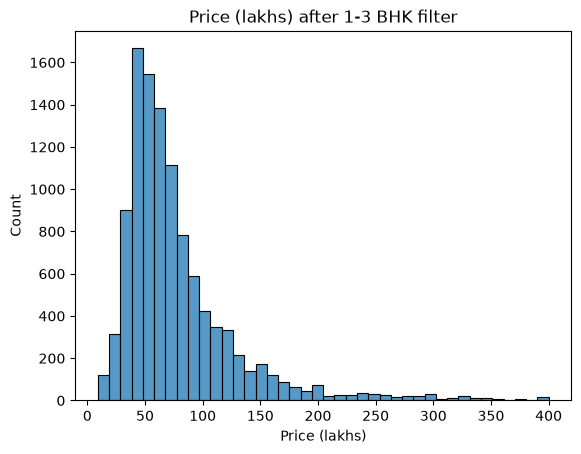

In [5]:
sns.histplot(clean["price"], bins=40)
plt.title("Price (lakhs) after 1-3 BHK filter")
plt.xlabel("Price (lakhs)")
plt.show()

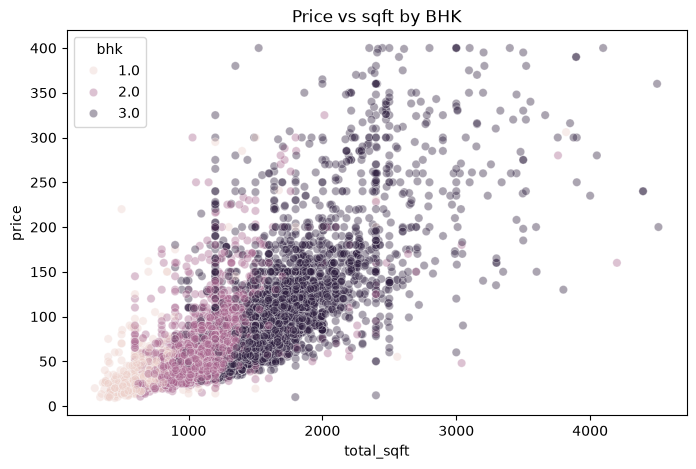

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=clean, x="total_sqft", y="price", hue="bhk", alpha=0.4)
plt.title("Price vs sqft by BHK")
plt.show()

bhk                         1.0    2.0      3.0
location                                       
Bommasandra                 NaN  37.46   50.280
Electronic City           30.24  40.55   70.000
Electronic City Phase I   35.50  49.80   71.000
Electronic City Phase II  35.00  33.50   40.445
HSR Layout                62.50  60.00  110.000


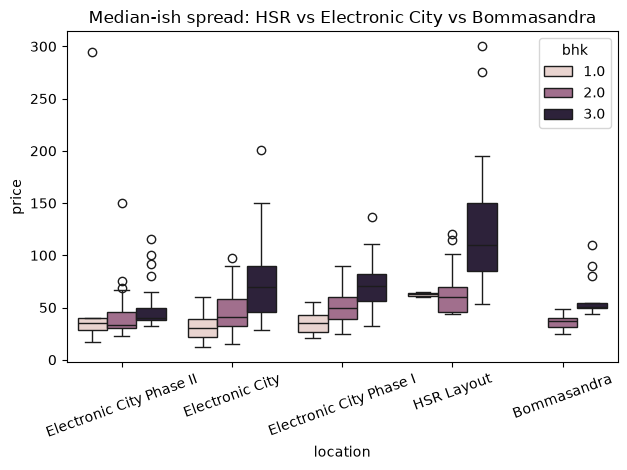

In [7]:
focus = ["HSR Layout", "Electronic City", "Electronic City Phase I",
         "Electronic City Phase II", "Bommasandra"]
subset = clean[clean["location"].isin(focus)]
print(subset.groupby(["location", "bhk"])["price"].median().unstack())
sns.boxplot(data=subset, x="location", y="price", hue="bhk")
plt.xticks(rotation=20)
plt.title("Median-ish spread: HSR vs Electronic City vs Bommasandra")
plt.tight_layout()
plt.show()

## What to read next

`python -m src.train` fits a median baseline, Linear Regression and a Random Forest, picks
between them by 5-fold CV **on the training rows**, scores the held-out test set once
afterwards, and writes `models/metadata.json` next to the saved model.

Expect **MAE ≈ 15.7 lakh, R² ≈ 0.72** — a median error around 16%. An earlier version of
this project reported 9.97, but that number came from a test set the outlier filter had
already cleaned up. The README has the full before/after and a table of the seven changes
that were measured and *didn't* help.

Training also calibrates an uncertainty range out-of-fold: an estimate of X is really
**0.73X to 1.33X, 80% of the time**. Measured against the held-out test set that interval
covers 79.4% of real prices — which is why `predict.py` prints a range and not just a number.

To turn an estimate here into a present-day number:

```
python -m src.predict --location "Electronic City Phase II" --bhk 2 --sqft 1000 --project 2030
```

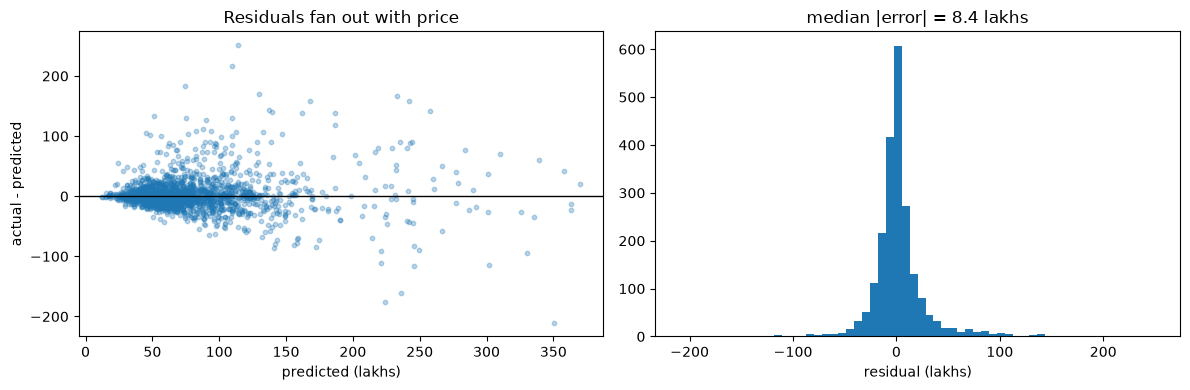

  0- 50 lakhs  n=  653  MAE=  8.51
 50-100 lakhs  n= 1042  MAE= 11.67
100-200 lakhs  n=  388  MAE= 27.18
200-400 lakhs  n=   74  MAE= 70.26


In [8]:
import joblib
import numpy as np
from sklearn.model_selection import train_test_split

from src.config import MODEL_PATH, RANDOM_STATE, TARGET, TEST_SIZE
from src.model import FEATURES

# Same split as train.py, and the test rows are never filtered.
_, test = train_test_split(clean, test_size=TEST_SIZE, random_state=RANDOM_STATE)
model = joblib.load(MODEL_PATH)
pred = model.predict(test[FEATURES])
resid = test[TARGET].to_numpy() - pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred, resid, alpha=0.3, s=10)
axes[0].axhline(0, color="k", lw=1)
axes[0].set(xlabel="predicted (lakhs)", ylabel="actual - predicted",
            title="Residuals fan out with price")
axes[1].hist(resid, bins=60)
axes[1].set(xlabel="residual (lakhs)",
            title=f"median |error| = {np.median(np.abs(resid)):.1f} lakhs")
plt.tight_layout()
plt.show()

for lo, hi in [(0, 50), (50, 100), (100, 200), (200, 400)]:
    band = test[(test[TARGET] >= lo) & (test[TARGET] < hi)]
    if len(band):
        err = np.abs(band[TARGET].to_numpy() - model.predict(band[FEATURES]))
        print(f"{lo:3d}-{hi:3d} lakhs  n={len(band):5d}  MAE={err.mean():6.2f}")

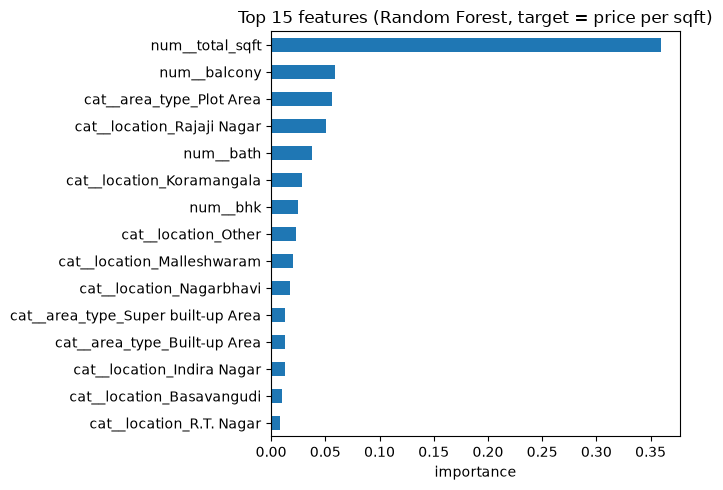

all 205 location columns together: 43.5% of total importance


In [9]:
# What the forest actually keys on. `.estimator_` is the Pipeline inside
# PricePerSqftRegressor; the one-hot step expands `location` into ~205 columns.
inner = model.estimator_
names = inner.named_steps["prep"].get_feature_names_out()
importance = pd.Series(inner.named_steps["model"].feature_importances_, index=names)

top = importance.nlargest(15).sort_values()
top.plot.barh(figsize=(7, 5))
plt.title("Top 15 features (Random Forest, target = price per sqft)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

share = importance[[n for n in names if n.startswith("cat__location")]].sum()
print(f"all {sum(n.startswith('cat__location') for n in names)} location columns together: "
      f"{100 * share:.1f}% of total importance")

## Reading the Linear Regression

The forest wins on accuracy, so it is what gets saved — but a forest cannot tell you
*why*. Linear Regression can: every locality gets one coefficient, in rupees per sqft,
directly interpretable as "this area costs X more than the baseline".

It is worth fitting the worse model just to read it.

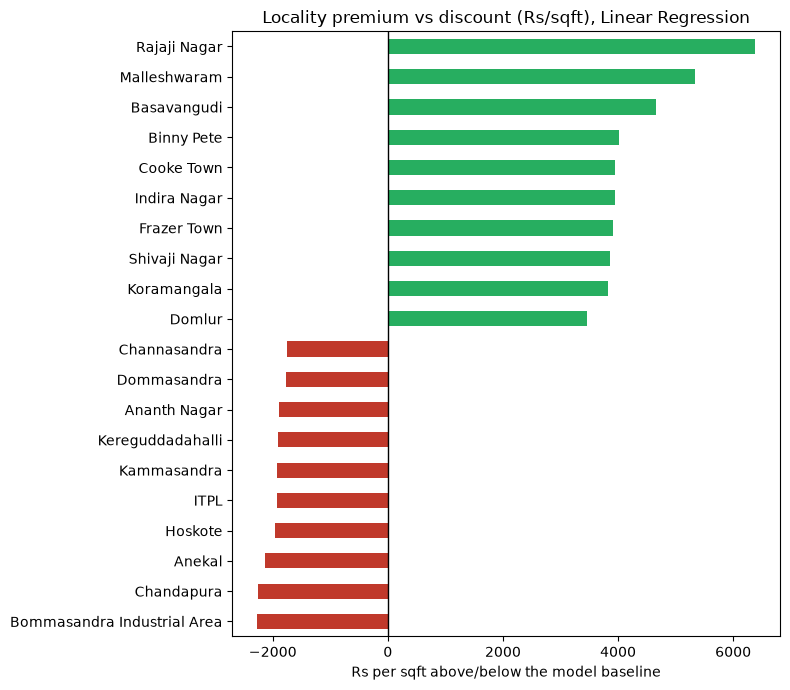

Numeric coefficients (Rs/sqft per 1 standard deviation, because they are scaled):
  total_sqft        +386
  bhk               -150
  bath              +274
  balcony           -119


In [10]:
from sklearn.linear_model import LinearRegression

from src.config import OUTLIER_N_STD
from src.model import build_pipeline
from src.preprocess import drop_pps_outliers

# Same protocol as train.py: split first, trim training rows only.
train_rows, _ = train_test_split(clean, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_rows = drop_pps_outliers(train_rows, OUTLIER_N_STD)

lr = build_pipeline(LinearRegression()).fit(train_rows[FEATURES], train_rows[TARGET])
inner_lr = lr.estimator_
names_lr = inner_lr.named_steps["prep"].get_feature_names_out()

# The model predicts price-per-sqft in LAKHS, so x100,000 puts coefficients in rupees.
coef = pd.Series(inner_lr.named_steps["model"].coef_ * 100_000, index=names_lr)

loc_coef = coef[[n for n in names_lr if n.startswith("cat__location")]]
loc_coef.index = [n.replace("cat__location_", "") for n in loc_coef.index]
extremes = pd.concat([loc_coef.nlargest(10), loc_coef.nsmallest(10)]).sort_values()

extremes.plot.barh(figsize=(8, 7), color=["#c0392b"] * 10 + ["#27ae60"] * 10)
plt.axvline(0, color="k", lw=1)
plt.title("Locality premium vs discount (Rs/sqft), Linear Regression")
plt.xlabel("Rs per sqft above/below the model baseline")
plt.tight_layout()
plt.show()

print("Numeric coefficients (Rs/sqft per 1 standard deviation, because they are scaled):")
for feature in ["total_sqft", "bhk", "bath", "balcony"]:
    print(f"  {feature:12s} {coef[f'num__{feature}']:+9.0f}")

## The classification task

Everything above is regression — "what is this worth". `python -m src.classify` answers a
different question: **is this flat priced above the typical rate for its locality?**

Same features, same split discipline, but metrics regression cannot give you — a confusion
matrix, precision, recall and ROC-AUC:

```
Baseline(most frequent)  acc=0.526  AUC=0.500
LogisticRegression       acc=0.639  AUC=0.663
RandomForestClassifier   acc=0.662  AUC=0.723
```

**The trap in that task is the same one that produced the fake MAE of 9.97, wearing
different clothes.** The label comes from `price`, so the locality medians that define it
must be computed from *training* rows only — a test flat is judged against the training
threshold, never its own. `tests/test_classify.py` has a test that fails if that ever
changes.